In [6]:
%pip install bjontegaard

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os

#GENERAL CONFIG
LABELS_FONTSIZE = 18
TICKS_FONTSIZE = 16
TITLE_FONTSIZE = 18
LEGEND_FONTSIZE = 16

FRAME_TYPE = 'all' #all, i or p

ANCHOR_PATH = "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/baseline.json"

TESTS_PATHS = [
    # "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_32entries.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_64entries.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_128entries.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_256entries.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_512entries.json",
    # "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_1024entries.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/poly_1int_deg11_16.json",
    "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/poly_25int_deg2_32.json",
    # "/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/relu.json",
]


TESTS_LABELS = [os.path.splitext(os.path.basename(p))[0] for p in TESTS_PATHS]


print(TESTS_LABELS)

LABEL_MAP = {
    "lut_asyn_4int_32entries": "LUT-32",
    "lut_asyn_4int_64entries": "LUT-64",
    "lut_asyn_4int_128entries": "LUT-128",
    "lut_asyn_4int_256entries": "LUT-256",
    "lut_asyn_4int_512entries": "LUT-512",
    "lut_asyn_4int_1024entries": "LUT-1024",
    "poly_1int_deg11_16": "Poly 11int 16deg",
    "poly_25int_deg2_32": "Poly 25int 2deg"
}

DATASET = None

['lut_asyn_4int_64entries', 'lut_asyn_4int_128entries', 'lut_asyn_4int_256entries', 'lut_asyn_4int_512entries', 'lut_asyn_4int_1024entries', 'poly_1int_deg11_16', 'poly_25int_deg2_32']


In [8]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from bjontegaard import bd_rate, bd_psnr


def extract_by_sequence(data, frame_type):
    results = defaultdict(lambda: defaultdict(dict))
    for dataset, sequences in data.items():
        for seq, entries in sequences.items():
            for key, v in entries.items():
                rate_idx = v["rate_idx"]
                bpp = v[f"ave_{frame_type}_frame_bpp"]
                psnr = v[f"ave_{frame_type}_frame_psnr"]
                results[dataset][seq][rate_idx] = (bpp, psnr)
    return results

In [9]:
# -*- coding: utf-8 -*-, 32
# Lê o JSON no formato mostrado e transforma em um DataFrame "tidy".
# Funciona tanto recebendo um caminho de arquivo quanto uma string JSON.

from pathlib import Path
import json
import pandas as pd

def metrics_json_to_df(src):
    """
    src: caminho para arquivo .json OU string JSON.
    retorna: pandas.DataFrame com colunas planas (dataset, sequence, rate_idx, ...).
    """
    # 1) Carregar o JSON
    if isinstance(src, (str, Path)) and Path(str(src)).exists():
        with open(src, "r", encoding="utf-8") as f:
            data = json.load(f)
    elif isinstance(src, (str, bytes)) and str(src).lstrip().startswith("{"):
        data = json.loads(src)
    else:
        raise ValueError("Passe um caminho existente para o arquivo .json ou uma string JSON válida.")

    # 2) Percorrer a estrutura e coletar linhas
    rows = []
    for dataset_name, sequences in data.items():                 # ex.: "UVG", "HEVC_B", ...
        for seq_name, rates in sequences.items():                # ex.: "Beauty_1920x1080_120", ...
            for rate_key, metrics in rates.items():              # ex.: "000", "001", ...
                # Copiar o dict de métricas e adicionar chaves de contexto
                m = dict(metrics)  # copia
                m["dataset"]  = dataset_name
                m["sequence"] = seq_name

                # rate_idx já vem no JSON como inteiro; o rate_key é string ("000", ...).
                # Mantemos o 'rate_idx' como coluna principal (int) e também guardamos o rótulo textual, se útil.
                m["rate_key"] = rate_key
                # opcional: garantir consistência (não é obrigatório)
                if "rate_idx" not in m:
                    # se não existir, derivar do rótulo textual
                    try:
                        m["rate_idx"] = int(rate_key)
                    except Exception:
                        pass

                # Evitar duplicatas redundantes (o JSON já inclui ds_name/seq internos)
                m.pop("ds_name", None)
                m.pop("seq", None)

                rows.append(m)

    # 3) Criar DataFrame
    df = pd.DataFrame.from_records(rows)

    # 4) Tipos e ordenação (opcional)
    if "rate_idx" in df.columns:
        df["rate_idx"] = pd.to_numeric(df["rate_idx"])
        df = df.sort_values(["dataset", "sequence", "rate_idx"]).reset_index(drop=True)
    else:
        df = df.sort_values(["dataset", "sequence", "rate_key"]).reset_index(drop=True)

    return df




In [10]:
df_results = metrics_json_to_df(ANCHOR_PATH)
df_results["experiment"] = "anchor"

for test in TESTS_PATHS:
    print(test)
    test_df = metrics_json_to_df(test)
    test_df["experiment"] = test.split("/")[-1].replace(".json", "")
    df_results = pd.concat([df_results, test_df], ignore_index=True)

# df_results.columns

/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_64entries.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_128entries.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_256entries.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_512entries.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/lut_asyn_4int_1024entries.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/poly_1int_deg11_16.json
/home/ruhan625/hwsigmoid_lascas2026/coding_outputs/complete/poly_25int_deg2_32.json


In [11]:
# 1) Lista de experiments únicos
df = df_results

experiments = df['experiment'].dropna().unique()
print("Experiments únicos:", experiments)

# 2) Para cada experiment, lista datasets únicos
#    (ignorando NaN em 'dataset')
exp_to_datasets = (
    df.dropna(subset=['experiment', 'dataset'])
      .groupby('experiment')['dataset']
      .unique()
      .sort_index()
)

print("\nDatasets por experiment:")
for exp, dsets in exp_to_datasets.items():
    print(f"  {exp}: {sorted(map(str, dsets))}")

# 3) Datasets que aparecem em TODOS os experiments
#    (forma 1: interseção de conjuntos)
if len(exp_to_datasets) == 0:
    common_datasets = set()
else:
    common_datasets = set(exp_to_datasets.iloc[0])
    for dsets in exp_to_datasets.iloc[1:]:
        common_datasets &= set(dsets)

print("\nDatasets presentes em TODOS os experiments:", sorted(map(str, common_datasets)))

# (alternativa equivalente, concisa)
# total_exps = df['experiment'].dropna().nunique()
# counts = (df.dropna(subset=['experiment','dataset'])
#             .groupby('dataset')['experiment'].nunique())
# common_datasets_alt = set(counts[counts == total_exps].index)

# Filtrar o df
df_filtered = df[df['dataset'].isin(common_datasets)].copy()

# (Opcional) ver o que foi removido
all_datasets = set(df['dataset'].dropna().unique())
removed = sorted(map(str, all_datasets - common_datasets))
print("\nDatasets removidos:", removed)

# Resultado final:
# df_filtered contém apenas linhas cujos 'dataset' aparecem em todos os 'experiment'
df_results = df_filtered

Experiments únicos: ['anchor' 'lut_asyn_4int_64entries' 'lut_asyn_4int_128entries'
 'lut_asyn_4int_256entries' 'lut_asyn_4int_512entries'
 'lut_asyn_4int_1024entries' 'poly_1int_deg11_16' 'poly_25int_deg2_32']

Datasets por experiment:
  anchor: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  lut_asyn_4int_1024entries: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  lut_asyn_4int_128entries: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  lut_asyn_4int_256entries: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  lut_asyn_4int_512entries: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  lut_asyn_4int_64entries: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  poly_1int_deg11_16: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']
  poly_25int_deg2_32: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']

Datasets presentes em TODOS os experiments: ['HEVC_B', 'HEVC_C', 'HEVC_D', 'HEVC_E', 'UVG']

Datasets removidos: []


In [12]:
import pandas as pd
import numpy as np

def averages_by_rate(df, experiment=None, dataset=None, frame_type='all'):
    """
    Filters the DataFrame and returns three NumPy arrays:
      - rate_vals : rate values (sorted)
      - bpp_means    : average bpp for each quality
      - psnr_means   : average psnr for each quality

    Any parameter can be set to None to skip filtering by that field.
    """
    cond = pd.Series(True, index=df.index)

    
    
    if dataset is not None:
        cond &= (df['dataset'] == dataset)
    cond &= (df['experiment'] == experiment)

    df_filtered = df[cond]

    if df_filtered.empty:
        raise ValueError("No data found with these parameters.")

    df_group = df_filtered.groupby('rate_idx').agg(
        bpp_mean=(f"ave_{frame_type}_frame_bpp", 'mean'),
        psnr_mean=(f"ave_{frame_type}_frame_psnr", 'mean')
        
    ).reset_index().sort_values('rate_idx')

    rate_vals = df_group['rate_idx'].to_numpy()
    bpp_means = df_group['bpp_mean'].to_numpy()
    psnr_means = df_group['psnr_mean'].to_numpy()

    return rate_vals, bpp_means, psnr_means

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '66.26'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimb

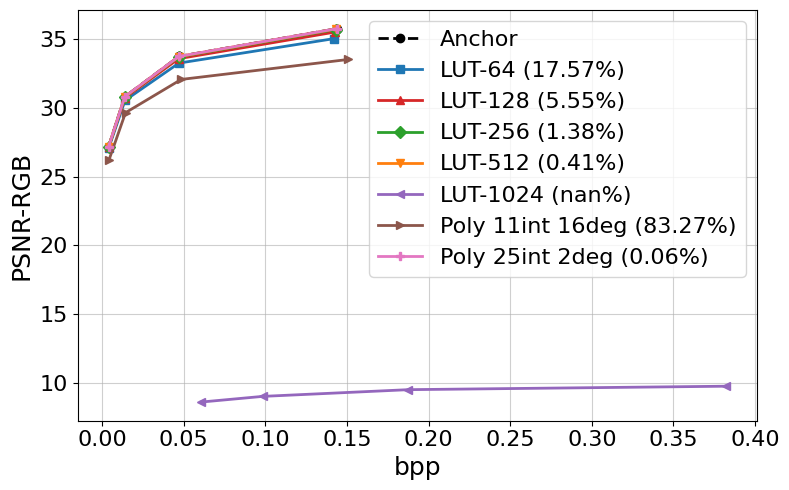

In [13]:
# colors = ['black', 'blue', 'orange', 'green', 'red', 'pink',]
colors = [
    "#000000",  # Preto -> linha de base / anchor
    "#1f77b4",  # Azul forte
    "#d62728",  # Vermelho científico
    "#2ca02c",  # Verde bem definido
    "#ff7f0e",  # Laranja destacado
    "#9467bd",  # Roxo sóbrio
    "#8c564b",  # Marrom científico
    "#e377c2",  # Rosa/magenta claro
    "#7f7f7f",  # Cinza neutro
    "#bcbd22"   # Amarelo mostarda
]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(8, 5))
plt.rcParams["font.family"] = "Nimbus Roman"


_, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=DATASET, frame_type=FRAME_TYPE)
plt.plot(
    bpp_anchor, psnr_anchor,
    label=f'Anchor',    
    linewidth=2,
    marker=markers[0],
    color=colors[0], linestyle='--',  # linha tracejada para o anchor
)


for i, exp in enumerate(TESTS_LABELS):    
    _, bpp, psnr = averages_by_rate(
        df_results,
        experiment=f"{exp}",
        frame_type=FRAME_TYPE,                        
        dataset=DATASET
    )

    try:
        bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    except:
        bdbd = float("NaN")

    plt.plot(
        bpp, psnr,
        label=f'{LABEL_MAP.get(exp, exp)} ({bdbd:.2f}%)',
        linewidth=2,
        marker=markers[(i+1)%len(markers)],
        color=colors[(i+1)%len(colors)],         
    )

plt.xlabel('bpp', fontsize=LABELS_FONTSIZE)
plt.ylabel('PSNR-RGB', fontsize=LABELS_FONTSIZE)
plt.legend(fontsize=LEGEND_FONTSIZE)   # aumenta a legenda
plt.tick_params(axis='both', labelsize=TICKS_FONTSIZE)  # aumenta os ticks dos eixos
plt.grid(True, linestyle='-', alpha=0.6)
# plt.xticks(np.arange(0, 0.4, 0.1))
# plt.yticks(np.arange(22, 37, 5))
# plt.xlim(0, 0.1)    # eixo X vai de 0 a 1.0
# plt.ylim(29, 36)    # eixo Y vai de 20 a 50
plt.tight_layout()   

# plt.savefig("/data/Ruhan/TCSVT2025/uniform_analysis.pdf", dpi=1200, bbox_inches="tight")   # formato PNG


In [14]:
for exp in experiments :        
    if exp == "anchor" : 
        print(f"dataset\t", end="|")
        continue
    print(f"{LABEL_MAP.get(exp, exp)}\t", end="|")
print()

for ds in df_results['dataset'].unique():
    _, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=ds, frame_type=FRAME_TYPE)
    experiments = df_results['experiment'].unique()
    print(f"{ds}\t", end="|")

    for exp in experiments :
        if exp == "anchor" : continue
        _, bpp, psnr = averages_by_rate(df_results,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=ds)
        bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        print(f"{bdbd:.2f}\t\t", end="|")
    print()

print(f"Average\t", end="|")
_, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=None, frame_type=FRAME_TYPE)
for exp in experiments :
    if exp == "anchor" : continue
    _, bpp, psnr = averages_by_rate(df_results,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=None)
    bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f"{bdbd:.2f}\t\t", end="|")
    

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '70.76'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc

dataset	|LUT-64	|LUT-128	|LUT-256	|LUT-512	|LUT-1024	|Poly 11int 16deg	|Poly 25int 2deg	|
HEVC_B	|15.89		|4.95		|1.27		|0.32		|nan		|74.36		|0.02		|
HEVC_C	|7.24		|2.31		|0.49		|0.18		|nan		|35.58		|-0.18		|
HEVC_D	|6.63		|2.05		|0.43		|0.27		|nan		|33.98		|0.17		|
HEVC_E	|29.62		|9.62		|2.34		|0.69		|nan		|145.48		|0.03		|
UVG	|27.45		|8.00		|2.04		|0.49		|nan		|139.39		|0.03		|
Average	|17.57		|5.55		|1.38		|0.41		|nan		|83.27		|0.06		|

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '45.67'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '55.04'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '70.76'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")


15.89		|4.95		|1.27		|0.32		|nan		|74.36		|0.02		|7.24		|2.31		|0.49		|0.18		|nan		|35.58		|-0.18		|6.63		|2.05		|0.43		|0.27		|nan		|33.98		|0.17		|29.62		|9.62		|2.34		|0.69		|nan		|145.48		|0.03		|27.45		|8.00		|2.04		|

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '45.67'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc

0.49		|nan		|139.39		|0.03		|17.57		|5.55		|1.38		|0.41		|nan		|83.27		|0.06		|

findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not

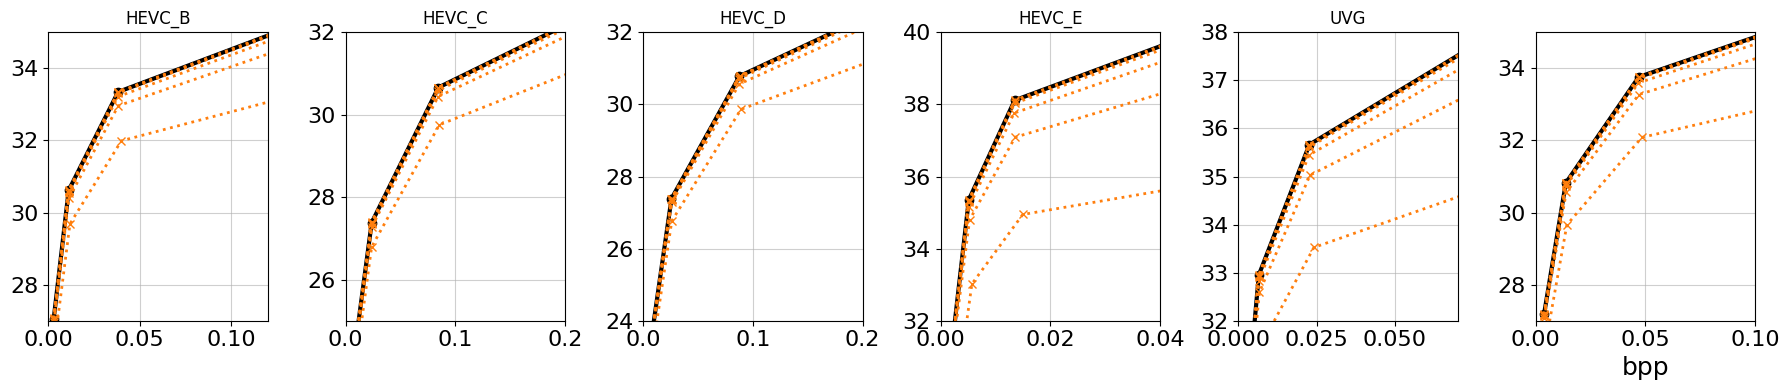

In [15]:
# colors = ['black', 'blue', 'orange', 'green', 'red', 'pink',]
colors = [
    "#000000",  # Preto -> linha de base / anchor
    "#1f77b4",  # Azul forte
    "#d62728",  # Vermelho científico
    "#2ca02c",  # Verde bem definido
    "#ff7f0e",  # Laranja destacado
    "#9467bd",  # Roxo sóbrio
    "#8c564b",  # Marrom científico
    "#e377c2",  # Rosa/magenta claro
    "#7f7f7f",  # Cinza neutro
    "#bcbd22"   # Amarelo mostarda
]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(18, 4))
plt.rcParams["font.family"] = "Nimbus Roman"

datasets = df_results['dataset'].unique().tolist()
datasets.append(None)

x_lim = [(0,0.12),(0,0.2),(0,0.2),(0,0.04),(0,0.07),(0,0.1)]
y_lim = [(27,35),(25,32),(24,32),(32,40),(32,38),(27,35)]

for idx, ds in enumerate(datasets):
    plt.subplot(1, len(datasets), idx+1)
    
    _, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=ds, frame_type=FRAME_TYPE)
    plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=3,
        marker=markers[0],
        color=colors[0], linestyle='-',  # linha tracejada para o anchor
    )  
    plt.title(ds)    
    experiments = df_results['experiment'].unique()    
    
    for exp in experiments :
        if exp == "anchor" : continue
        _, bpp, psnr = averages_by_rate(df_results,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=ds)
        bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        print(f"{bdbd:.2f}\t\t", end="|")

        try:
            bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        except:
            bdbd = float("NaN")

        plt.plot(
            bpp, psnr,
            label=f'{exp} ({bdbd:.2f})',
            linewidth=2,
            marker='x',
            color='#ff7f0e',
            linestyle=':',            
        )
    plt.tick_params(axis='both', labelsize=TICKS_FONTSIZE)  # aumenta os ticks dos eixos
    plt.ylim(*y_lim[idx])    
    plt.xlim(*x_lim[idx])    
    plt.grid(True, linestyle='-', alpha=0.6)
    
    # plt.ylim(24, 28)    # eixo Y vai de 20 a 50
    # plt.xlim(0, 0.25)    # eixo X vai de 0 a 1.0


# for i, exp in enumerate(TESTS_LABELS):    
#     _, bpp, psnr = averages_by_rate(
#         df_results,
#         experiment=f"{exp}",
#         frame_type=FRAME_TYPE,                        
#         dataset=DATASET
#     )

#     try:
#         bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
#     except:
#         bdbd = float("NaN")

#     plt.plot(
#         bpp, psnr,
#         label=f'{exp} ({bdbd:.2f})',
#         linewidth=2,
#         marker=markers[(i+1)%len(markers)],
#         color=colors[(i+1)%len(colors)],         
#     )

plt.xlabel('bpp', fontsize=LABELS_FONTSIZE)
# plt.ylabel('PSNR-RGB', fontsize=LABELS_FONTSIZE)
# plt.legend(fontsize=LEGEND_FONTSIZE)   # aumenta a legenda
plt.tick_params(axis='both', labelsize=TICKS_FONTSIZE)  # aumenta os ticks dos eixos
plt.grid(True, linestyle='-', alpha=0.6)
# plt.xticks(np.arange(0, 0.4, 0.1))
# plt.yticks(np.arange(22, 37, 5))
# plt.xlim(0, 0.03)    # eixo X vai de 0 a 1.0
# plt.ylim(24, 28)    # eixo Y vai de 20 a 50
plt.tight_layout()   

# plt.savefig("/data/Ruhan/TCSVT2025/uniform_analysis.pdf", dpi=1200, bbox_inches="tight")   # formato PNG


/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '70.76'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")


15.89		|4.95		|1.27		|0.32		|nan		|74.36		|0.02		|7.24		|2.31		|0.49		|0.18		|nan		|35.58		|-0.18		|6.63		|2.05		|0.43		|0.27		|nan		|33.98		|0.17		|29.62		|9.62		|2.34		|0.69		|nan		|145.48		|0.03		|27.45		|8.00		|2.04		|0.49		|

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '45.67'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc

nan		|139.39		|0.03		|17.57		|5.55		|1.38		|0.41		|nan		|83.27		|0.06		|

findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not found.
findfont: Font family 'Nimbus Roman' not

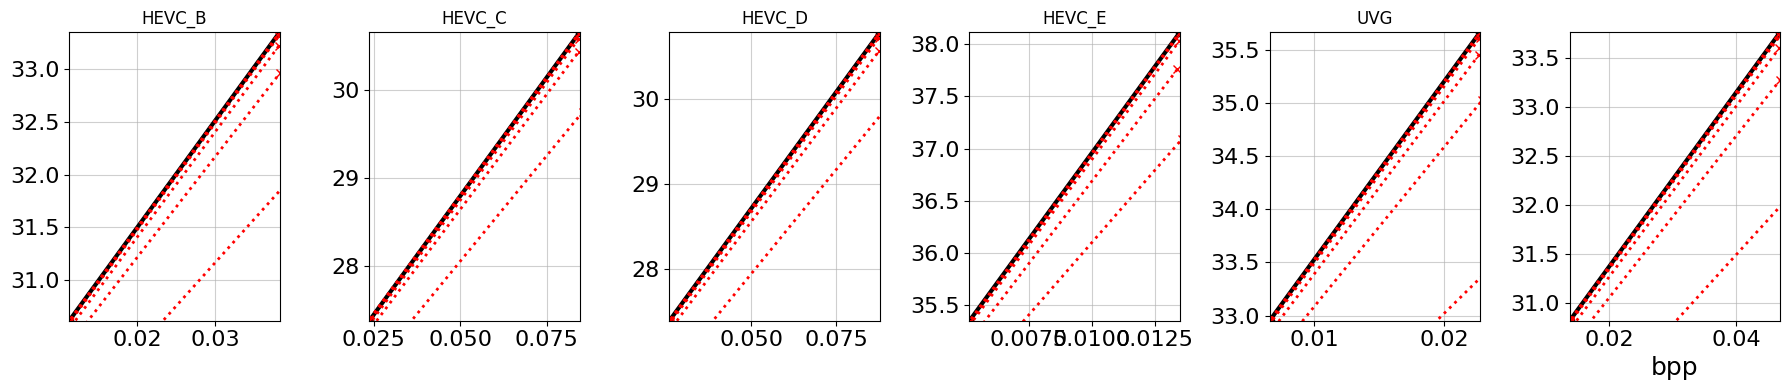

In [16]:
# colors = ['black', 'blue', 'orange', 'green', 'red', 'pink',]
colors = [
    "#000000",  # Preto -> linha de base / anchor
    "#1f77b4",  # Azul forte
    "#d62728",  # Vermelho científico
    "#2ca02c",  # Verde bem definido
    "#ff7f0e",  # Laranja destacado
    "#9467bd",  # Roxo sóbrio
    "#8c564b",  # Marrom científico
    "#e377c2",  # Rosa/magenta claro
    "#7f7f7f",  # Cinza neutro
    "#bcbd22"   # Amarelo mostarda
]

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'P', 'X']
linestyles = ['-', '--', '-.', ':']

plt.figure(figsize=(18, 4))
plt.rcParams["font.family"] = "Nimbus Roman"

datasets = df_results['dataset'].unique().tolist()
datasets.append(None)

x_lim = [(0,0.12),(0,0.2),(0,0.2),(0,0.04),(0,0.07),(0,0.1)]
y_lim = [(27,35),(25,32),(24,32),(32,40),(32,38),(27,35)]

for idx, ds in enumerate(datasets):
    plt.subplot(1, len(datasets), idx+1)
    
    _, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=ds, frame_type=FRAME_TYPE)
    plt.plot(
        bpp_anchor, psnr_anchor,
        label=f'Anchor',    
        linewidth=3,
        marker=markers[0],
        color=colors[0], linestyle='-',  # linha tracejada para o anchor
    )  
    plt.title(ds)    
    experiments = df_results['experiment'].unique()    
    
    for exp in experiments :
        if exp == "anchor" : continue
        _, bpp, psnr = averages_by_rate(df_results,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=ds)
        bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        print(f"{bdbd:.2f}\t\t", end="|")

        try:
            bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
        except:
            bdbd = float("NaN")

        plt.plot(
            bpp, psnr,
            label=f'{exp} ({bdbd:.2f})',
            linewidth=2,
            marker='x',
            color='red',
            linestyle=':',            
        )
    plt.tick_params(axis='both', labelsize=TICKS_FONTSIZE)  # aumenta os ticks dos eixos
    plt.ylim(psnr_anchor[1],psnr_anchor[2])
    plt.xlim(bpp_anchor[1],bpp_anchor[2])    
    plt.grid(True, linestyle='-', alpha=0.6)
    
    # plt.ylim(24, 28)    # eixo Y vai de 20 a 50
    # plt.xlim(0, 0.25)    # eixo X vai de 0 a 1.0


# for i, exp in enumerate(TESTS_LABELS):    
#     _, bpp, psnr = averages_by_rate(
#         df_results,
#         experiment=f"{exp}",
#         frame_type=FRAME_TYPE,                        
#         dataset=DATASET
#     )

#     try:
#         bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
#     except:
#         bdbd = float("NaN")

#     plt.plot(
#         bpp, psnr,
#         label=f'{exp} ({bdbd:.2f})',
#         linewidth=2,
#         marker=markers[(i+1)%len(markers)],
#         color=colors[(i+1)%len(colors)],         
#     )

plt.xlabel('bpp', fontsize=LABELS_FONTSIZE)
# plt.ylabel('PSNR-RGB', fontsize=LABELS_FONTSIZE)
# plt.legend(fontsize=LEGEND_FONTSIZE)   # aumenta a legenda
plt.tick_params(axis='both', labelsize=TICKS_FONTSIZE)  # aumenta os ticks dos eixos
plt.grid(True, linestyle='-', alpha=0.6)
# plt.xticks(np.arange(0, 0.4, 0.1))
# plt.yticks(np.arange(22, 37, 5))
# plt.xlim(0, 0.03)    # eixo X vai de 0 a 1.0
# plt.ylim(24, 28)    # eixo Y vai de 20 a 50
plt.tight_layout()   

# plt.savefig("/data/Ruhan/TCSVT2025/uniform_analysis.pdf", dpi=1200, bbox_inches="tight")   # formato PNG


In [17]:
for ds in df_results['dataset'].unique():
    df_dataset = df_results[df_results['dataset'] == ds]
    for seq in df_dataset['sequence'].unique():
        df_sequence = df_dataset[df_dataset['sequence'] == seq]        
        _, bpp_anchor, psnr_anchor = averages_by_rate(df_sequence, experiment="anchor", dataset=ds, frame_type=FRAME_TYPE)
        experiments = df_sequence['experiment'].unique()
        print(f"{seq}\t", end="|")

        for exp in experiments :
            if exp == "anchor" : continue
            _, bpp, psnr = averages_by_rate(df_sequence,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=ds)
            bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
            print(f"{bdbd:.2f}\t\t", end="|")
        print()

print(f"Average\t", end="|")
_, bpp_anchor, psnr_anchor = averages_by_rate(df_results, experiment="anchor", dataset=None, frame_type=FRAME_TYPE)
for exp in experiments :
    if exp == "anchor" : continue
    _, bpp, psnr = averages_by_rate(df_results,experiment=f"{exp}",frame_type=FRAME_TYPE,dataset=None)
    bdbd = bd_rate(bpp_anchor, psnr_anchor, bpp, psnr, 'akima')
    print(f"{bdbd:.2f}\t\t", end="|")
    

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '73.96'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '68.84'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625

BQTerrace_1920x1080_60	|14.92		|4.39		|1.33		|0.57		|nan		|83.84		|0.08		|
BasketballDrive_1920x1080_50	|14.81		|4.51		|1.07		|0.26		|nan		|73.25		|0.01		|
Cactus_1920x1080_50	|15.57		|4.82		|1.46		|0.43		|nan		|73.68		|-0.02		|
Kimono1_1920x1080_24	|18.42		|6.11		|1.43		|0.27		|nan		|74.42		|0.06		|
ParkScene_1920x1080_24	|13.61		|4.04		|0.87		|0.09		|nan		|58.78		|-0.09		|
BQMall_832x480_60	|8.06		|3.20		|0.30		|-0.02		|nan		|41.07		|-0.51		|


/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '65.89'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc

BasketballDrill_832x480_50	|9.23		|2.63		|0.69		|0.15		|nan		|47.47		|-0.27		|
PartyScene_832x480_50	|5.14		|1.38		|0.58		|0.31		|nan		|25.00		|0.00		|
RaceHorses_832x480_30	|6.17		|1.73		|0.53		|0.30		|nan		|27.45		|0.01		|
BQSquare_416x240_60	|5.61		|1.49		|0.34		|0.24		|nan		|32.87		|0.34		|
BasketballPass_416x240_50	|8.90		|2.98		|0.56		|0.56		|nan		|45.14		|0.03		|
BlowingBubbles_416x240_50	|6.51		|2.03		|0.48		|0.07		|nan		|32.56		|0.13		|
RaceHorses_416x240_30	|5.18		|1.58		|0.28		|0.04		|nan		|23.43		|-0.03		|


/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10

FourPeople_1280x720_60	|22.13		|7.37		|1.65		|0.60		|nan		|107.53		|0.03		|
Johnny_1280x720_60	|38.08		|12.03		|3.20		|1.04		|nan		|195.61		|-0.02		|
KristenAndSara_1280x720_60	|31.92		|10.32		|2.47		|0.54		|nan		|155.87		|0.13		|
Beauty_1920x1080_120	|46.04		|17.73		|4.23		|0.70		|nan		|381.31		|0.17		|
Bosphorus_1920x1080_120	|38.08		|11.72		|3.05		|0.80		|nan		|233.60		|-0.05		|
HoneyBee_1920x1080_120	|25.88		|7.09		|2.08		|0.48		|nan		|96.29		|0.09		|
Jockey_1920x1080_120	|27.74		|7.58		|1.77		|0.45		|nan		|114.25		|0.02		|


/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '41.58'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:49: UserWarning: Curves do not overlap. BD cannot be calculated.
  warnings.warn("Curves do not overlap. BD cannot be calculated.")
/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '53.69'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/ruhan625

ReadySteadyGo_1920x1080_120	|16.95		|5.17		|1.29		|0.36		|nan		|75.42		|0.01		|
ShakeNDry_1920x1080_120	|19.92		|5.65		|1.30		|0.31		|nan		|111.09		|-0.04		|
YachtRide_1920x1080_120	|18.26		|5.58		|1.47		|0.36		|nan		|102.53		|-0.00		|
Average	|17.57		|5.55		|1.38		|0.41		|nan		|83.27		|0.06		|

/home/ruhan625/miniconda3/envs/dcvc_qatkd/lib/python3.10/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '66.26'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(


In [18]:
df_results[df_results['dataset'] == 'HEVC_B']

,frame_pixel_num,i_frame_num,p_frame_num,ave_i_frame_bpp,ave_i_frame_psnr,ave_i_frame_msssim,test_time,ave_p_frame_bpp,ave_p_frame_psnr,ave_p_frame_msssim,ave_all_frame_bpp,ave_all_frame_psnr,ave_all_frame_msssim,rate_idx,qp_i,qp_p,dataset,sequence,rate_key,experiment
0,2073600,3,93,0.041601,24.693740,0.0,24.743766,0.002363,25.980075,0.0,0.003589,25.939877,0.0,0,0,0,HEVC_B,BQTerrace_1920x1080_60,000,anchor
1,2073600,3,93,0.129154,28.872102,0.0,24.694514,0.009065,29.805443,0.0,0.012818,29.776276,0.0,1,21,21,HEVC_B,BQTerrace_1920x1080_60,001,anchor
2,2073600,3,93,0.336228,32.321461,0.0,24.963764,0.036056,32.099866,0.0,0.045436,32.106791,0.0,2,42,42,HEVC_B,BQTerrace_1920x1080_60,002,anchor
3,2073600,3,93,0.936996,35.476349,0.0,24.743877,0.175429,33.631624,0.0,0.199228,33.689272,0.0,3,63,63,HEVC_B,BQTerrace_1920x1080_60,003,anchor
4,2073600,3,93,0.020313,29.325199,0.0,25.408898,0.002238,27.242782,0.0,0.002803,27.307857,0.0,0,0,0,HEVC_B,BasketballDrive_1920x1080_50,000,anchor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,2073600,3,93,0.240399,38.462445,0.0,237.596356,0.081514,37.585205,0.0,0.086479,37.612619,0.0,3,63,63,HEVC_B,Kimono1_1920x1080_24,003,poly_25int_deg2_32
660,2073600,3,93,0.022046,26.361801,0.0,236.712790,0.002468,26.735016,0.0,0.003080,26.723353,0.0,0,0,0,HEVC_B,ParkScene_1920x1080_24,000,poly_25int_deg2_32
661,2073600,3,93,0.084253,29.622137,0.0,237.057810,0.011463,30.012307,0.0,0.013738,30.000114,0.0,1,21,21,HEVC_B,ParkScene_1920x1080_24,001,poly_25int_deg2_32
662,2073600,3,93,0.267501,33.080977,0.0,237.155824,0.041708,32.902441,0.0,0.048764,32.908020,0.0,2,42,42,HEVC_B,ParkScene_1920x1080_24,002,poly_25int_deg2_32
